# VaR and Backtesting — MFE230H Problem Set 2

## Notebook 2 — Question 7: Backtesting

Question 7 asks:

> Given the VaR for August 1, 2026, how often do exceptions occur in the preceding 500 days, where an exception is a day when the realized loss exceeds VaR? Compare:
>
> 1. Parametric VaR
> 2. Historical-simulation VaR using a 100-day window
> 3. Historical-simulation VaR using a 500-day window

This notebook reads the output files already created by `01_VaR_Analysis.ipynb`.
No VaR model is re-estimated here.

## Process Used in Code 02

The backtesting analysis is implemented through the following steps:

1. **Set up the project paths.**  
   The notebook identifies the `VaR_Backtesting_as2` project root and connects to the existing `data/`, `results/tables/`, and `results/figures/` directories.

2. **Load the results from Code 01.**  
   The notebook imports the VaR estimates and portfolio information already generated in Notebook 01:
   - `Q02_parametric_var.csv`
   - `Q03_historical_var_100.csv`
   - `Q06_historical_var_500.csv`
   - `stock_prices.csv`
   - `Q02_initial_holdings.csv`

   This avoids re-estimating the VaR models and keeps the backtesting analysis separate from the forecasting stage.

3. **Reconstruct the buy-and-hold portfolio.**  
   The fixed number of shares from the initial holdings is multiplied by the daily stock prices. The total portfolio value is obtained by summing the market value of all ten positions each day.

4. **Calculate realized daily losses.**  
   Daily portfolio loss is defined as the previous day's portfolio value minus the current day's portfolio value:

   \[
   L_t = V_{t-1} - V_t
   \]

   A positive value represents a loss, while a negative value represents a gain.

5. **Determine the relevant VaR date.**  
   Since August 1, 2026 is not a trading day, the analysis uses **July 31, 2026**, the last available trading day on or before the assignment date. All three VaR methods use this same effective forecast date.

6. **Select the preceding 500 trading days.**  
   The backtesting sample contains exactly 500 trading-day observations, covering the period from **August 1, 2024 through July 30, 2026**.

7. **Identify VaR exceptions.**  
   For each VaR method, an exception occurs when the realized portfolio loss exceeds the corresponding VaR threshold:

   \[
   I_t = \mathbf{1}(L_t > VaR)
   \]

   The observed exception rate is calculated as

   \[$
   \hat{p}
   =
   \frac{\text{Number of Exceptions}}{500}$
   \]

8. **Compare observed exception rates with the 5% benchmark.**  
   Because the VaR confidence level is 95%, the expected exception rate is 5%. Over 500 trading days, this corresponds to approximately

   \[
   500 \times 0.05 = 25
   \]

   expected exceptions.

9. **Create backtesting figures.**  
   The first figure plots realized daily portfolio losses together with the three VaR thresholds, making the exception days visible. The second figure compares the observed exception rates across the three VaR methods with the 5% benchmark.

10. **Save reproducible outputs.**  
    The notebook saves the backtesting summary and exception-day tables in `results/tables/`, while the backtesting figures are saved in `results/figures/`.

## 0. Backtesting idea

For each method, take the VaR forecast at the last available trading date on or before August 1, 2026.

Define the realized dollar loss on trading day \(t\) as

\[
L_t = V_{t-1} - V_t.
\]

A VaR exception occurs when

\[
L_t > VaR.
\]

Because the confidence level is 95%, a well-calibrated VaR model has an expected exception probability of approximately 5%. Over 500 trading observations, this corresponds to approximately

\[
500 \times 0.05 = 25
\]

exceptions.

## 1. Project setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)

    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path

    raise FileNotFoundError(
        "Could not find pyproject.toml. "
        "Open this notebook from inside the VaR_Backtesting_as2 project."
    )

ROOT = find_project_root()

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"

TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)

Project root: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2


## 2. Load the outputs from Notebook 1

Code 01 already saved exactly the files needed for Question 7:

- `data/processed/Q02_parametric_var.csv`
- `data/processed/Q03_historical_var_100.csv`
- `data/processed/Q06_historical_var_500.csv`
- `data/raw/stock_prices.csv`
- `results/tables/Q02_initial_holdings.csv`

We therefore use those files directly rather than creating a new master forecast file.

In [2]:
PARAM_FILE = DATA_PROCESSED / "Q02_parametric_var.csv"
HIST100_FILE = DATA_PROCESSED / "Q03_historical_var_100.csv"
HIST500_FILE = DATA_PROCESSED / "Q06_historical_var_500.csv"
PRICE_FILE = DATA_RAW / "stock_prices.csv"
HOLDINGS_FILE = TABLES / "Q02_initial_holdings.csv"

required_files = [
    PARAM_FILE,
    HIST100_FILE,
    HIST500_FILE,
    PRICE_FILE,
    HOLDINGS_FILE,
]

missing_files = [str(p) for p in required_files if not p.exists()]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n"
        + "\n".join(missing_files)
        + "\n\nRun Notebook 01 through Question 6 first."
    )

print("All required files found.")

All required files found.


In [4]:
parametric = pd.read_csv(
    PARAM_FILE,
    parse_dates=["date", "previous_date"]
)

hist100 = pd.read_csv(
    HIST100_FILE,
    parse_dates=["date", "previous_date"]
)

hist500 = pd.read_csv(
    HIST500_FILE,
    parse_dates=["date", "previous_date"]
)

prices = pd.read_csv(
    PRICE_FILE,
    index_col=0,
    parse_dates=True
)

holdings = pd.read_csv(
    HOLDINGS_FILE
)

prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()

print("Parametric VaR:", parametric.shape)
print("Historical VaR 100:", hist100.shape)
print("Historical VaR 500:", hist500.shape)
print("Stock prices:", prices.shape)

print("\nHoldings:")
display(holdings)

Parametric VaR: (981, 6)
Historical VaR 100: (981, 6)
Historical VaR 500: (981, 5)
Stock prices: (1550, 10)

Holdings:


,ticker,initial_price,initial_weight,initial_allocation,shares
0,GME,28.639999,0.1,1000000.0,34916.201861
1,ROKU,68.000000,0.1,1000000.0,14705.882353
2,DKS,96.773743,0.1,1000000.0,10333.381477
3,BBWI,33.403267,0.1,1000000.0,29937.191557
4,DKNG,16.059999,0.1,1000000.0,62266.502693
5,CVNA,6.598000,0.1,1000000.0,151561.077976
6,RH,255.910004,0.1,1000000.0,3907.623718
7,W,52.709999,0.1,1000000.0,18971.732449
8,DDS,240.452103,0.1,1000000.0,4158.832420
9,BB,5.940000,0.1,1000000.0,168350.166728


## 3. Reconstruct the buy-and-hold portfolio value

Notebook 01 forms the portfolio on August 31, 2022 and keeps the number of shares fixed. We therefore reconstruct the portfolio value using the saved share quantities:

\[
V_t = \sum_i N_i P_{i,t}.
\]

Daily realized dollar loss is then

\[
L_t = V_{t-1} - V_t.
\]

Positive values represent losses and negative values represent gains.

In [6]:
TICKERS = holdings["ticker"].tolist()

shares = (
    holdings
    .set_index("ticker")["shares"]
    .reindex(TICKERS)
)

prices_bt = (
    prices[TICKERS]
    .copy()
    .dropna()
)

position_values = prices_bt.mul(
    shares,
    axis=1
)

portfolio_value = position_values.sum(axis=1)
portfolio_value.name = "portfolio_value"

portfolio_loss = -portfolio_value.diff()
portfolio_loss.name = "portfolio_loss"

realized = pd.concat(
    [portfolio_value, portfolio_loss],
    axis=1
).dropna()

print("Realized portfolio series:")
display(realized.head())

print("\nDate range:")
print(realized.index.min().date(), "to", realized.index.max().date())

Realized portfolio series:


,portfolio_value,portfolio_loss
Date,,
2020-06-02,1.377724e+07,-987581.706040
2020-06-03,1.345681e+07,320425.922910
2020-06-04,1.319094e+07,265868.009053
2020-06-05,1.350052e+07,-309574.981306
2020-06-08,1.368962e+07,-189103.270409



Date range:
2020-06-02 to 2026-07-31


## 4. Identify the VaR date and the three VaR thresholds

August 1, 2026 is not necessarily a trading day. The code therefore uses the **last available VaR forecast date on or before August 1, 2026** for each method.

The three VaR measures are already in dollar units, so they can be compared directly with realized daily dollar losses.

In [8]:
TARGET_DATE = pd.Timestamp("2026-08-01")

def latest_row_on_or_before(df, target_date):
    x = df.loc[df["date"] <= target_date].copy()

    if x.empty:
        raise ValueError(
            f"No VaR forecast is available on or before {target_date.date()}."
        )

    return x.sort_values("date").iloc[-1]

param_row = latest_row_on_or_before(
    parametric,
    TARGET_DATE
)

hist100_row = latest_row_on_or_before(
    hist100,
    TARGET_DATE
)

hist500_row = latest_row_on_or_before(
    hist500,
    TARGET_DATE
)

thresholds = pd.DataFrame({
    "method": [
        "Parametric VaR — 100-day",
        "Historical VaR — 100-day",
        "Historical VaR — 500-day",
    ],
    "var_date": [
        param_row["date"],
        hist100_row["date"],
        hist500_row["date"],
    ],
    "var_dollar": [
        param_row["parametric_var_dollar"],
        hist100_row["historical_var_dollar_100"],
        hist500_row["historical_var_dollar_500"],
    ],
})

print("Assignment target date:", TARGET_DATE.date())
display(
    thresholds.style.format({
        "var_dollar": "${:,.0f}",
    })
)

Assignment target date: 2026-08-01


,method,var_date,var_dollar
0,Parametric VaR — 100-day,2026-07-31 00:00:00,"$807,196"
1,Historical VaR — 100-day,2026-07-31 00:00:00,"$703,172"
2,Historical VaR — 500-day,2026-07-31 00:00:00,"$892,489"


### Check that all three methods use the same effective forecast date

Ideally, all three should correspond to the same last trading day on or before August 1, 2026.

In [10]:
unique_var_dates = thresholds["var_date"].dt.normalize().unique()

if len(unique_var_dates) == 1:
    VAR_DATE = pd.Timestamp(unique_var_dates[0])
    print("All three methods use:", VAR_DATE.date())
else:
    print("Warning: the three files do not use the same last forecast date.")
    display(thresholds)
    VAR_DATE = thresholds["var_date"].min()
    print(
        "For a common preceding-500-day sample, using:",
        VAR_DATE.date()
    )

All three methods use: 2026-07-31


## 5. Select the preceding 500 trading days

We select the 500 realized portfolio-loss observations immediately before the common VaR forecast date.

The forecast date itself is excluded because the question asks for the **preceding** 500 days.

In [12]:
backtest = (
    realized.loc[
        realized.index < VAR_DATE
    ]
    .tail(500)
    .copy()
)

if len(backtest) != 500:
    raise ValueError(
        f"Expected 500 preceding trading observations, "
        f"but found {len(backtest)}."
    )

print("Backtesting observations:", len(backtest))
print("First backtesting date:", backtest.index.min().date())
print("Last backtesting date :", backtest.index.max().date())

display(backtest.head())

Backtesting observations: 500
First backtesting date: 2024-08-01
Last backtesting date : 2026-07-30


,portfolio_value,portfolio_loss
Date,,
2024-08-01,1.509429e+07,118549.795037
2024-08-02,1.420295e+07,891343.202490
2024-08-05,1.390349e+07,299454.585340
2024-08-06,1.411503e+07,-211532.458448
2024-08-07,1.358003e+07,534996.026516


## 6. Count exceptions

For each VaR method, an exception indicator is

\[
I_t = \mathbf{1}(L_t > VaR).
\]

The exception rate is

\[$
\hat{p}
=
\frac{\text{number of exceptions}}{500}.$
\]

For a 95% VaR, the benchmark is 5%, or approximately 25 exceptions in 500 observations.

In [14]:
EXPECTED_RATE = 0.05
EXPECTED_EXCEPTIONS = 500 * EXPECTED_RATE

summary_rows = []
exception_frames = []

for _, row in thresholds.iterrows():

    method = row["method"]
    var_dollar = float(row["var_dollar"])
    var_date = pd.Timestamp(row["var_date"])

    exceptions = (
        backtest["portfolio_loss"] > var_dollar
    )

    n_exceptions = int(
        exceptions.sum()
    )

    exception_rate = (
        n_exceptions / len(backtest)
    )

    summary_rows.append({
        "method": method,
        "var_date": var_date,
        "var_dollar": var_dollar,
        "observations": len(backtest),
        "exceptions": n_exceptions,
        "exception_rate": exception_rate,
        "expected_exception_rate": EXPECTED_RATE,
        "expected_exceptions": EXPECTED_EXCEPTIONS,
        "difference_from_expected": (
            n_exceptions - EXPECTED_EXCEPTIONS
        ),
    })

    tmp = (
        backtest.loc[
            exceptions,
            ["portfolio_value", "portfolio_loss"]
        ]
        .copy()
    )

    tmp["method"] = method
    tmp["var_dollar"] = var_dollar
    tmp.index.name = "date"

    exception_frames.append(
        tmp.reset_index()
    )

backtest_summary = pd.DataFrame(
    summary_rows
)

exception_days = pd.concat(
    exception_frames,
    ignore_index=True
)

display(
    backtest_summary.style.format({
        "var_dollar": "${:,.0f}",
        "exception_rate": "{:.2%}",
        "expected_exception_rate": "{:.2%}",
        "expected_exceptions": "{:.0f}",
        "difference_from_expected": "{:+.0f}",
    })
)

,method,var_date,var_dollar,observations,exceptions,exception_rate,expected_exception_rate,expected_exceptions,difference_from_expected
0,Parametric VaR — 100-day,2026-07-31 00:00:00,"$807,196",500,27,5.40%,5.00%,25,+2
1,Historical VaR — 100-day,2026-07-31 00:00:00,"$703,172",500,41,8.20%,5.00%,25,+16
2,Historical VaR — 500-day,2026-07-31 00:00:00,"$892,489",500,20,4.00%,5.00%,25,-5


In [17]:
print(backtest_summary.to_string(index=False))

                  method   var_date    var_dollar  observations  exceptions  exception_rate  expected_exception_rate  expected_exceptions  difference_from_expected
Parametric VaR — 100-day 2026-07-31 807196.088242           500          27           0.054                     0.05                 25.0                       2.0
Historical VaR — 100-day 2026-07-31 703172.210028           500          41           0.082                     0.05                 25.0                      16.0
Historical VaR — 500-day 2026-07-31 892488.986470           500          20           0.040                     0.05                 25.0                      -5.0


## 7. Save Question 7 tables

The main summary table is saved separately from the detailed list of exception days.

In [18]:
summary_path = (
    TABLES /
    "Q07_backtesting_results.csv"
)

exception_path = (
    TABLES /
    "Q07_exception_days.csv"
)

backtest_summary.to_csv(
    summary_path,
    index=False
)

exception_days.to_csv(
    exception_path,
    index=False
)

print("Saved:", summary_path)
print("Saved:", exception_path)

Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/tables/Q07_backtesting_results.csv
Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/tables/Q07_exception_days.csv


## 8. Figure — realized losses versus August 2026 VaR thresholds

The figure shows the actual daily portfolio losses over the preceding 500 trading days together with the three fixed VaR thresholds.

A realized-loss observation above a VaR line is an exception for that method.

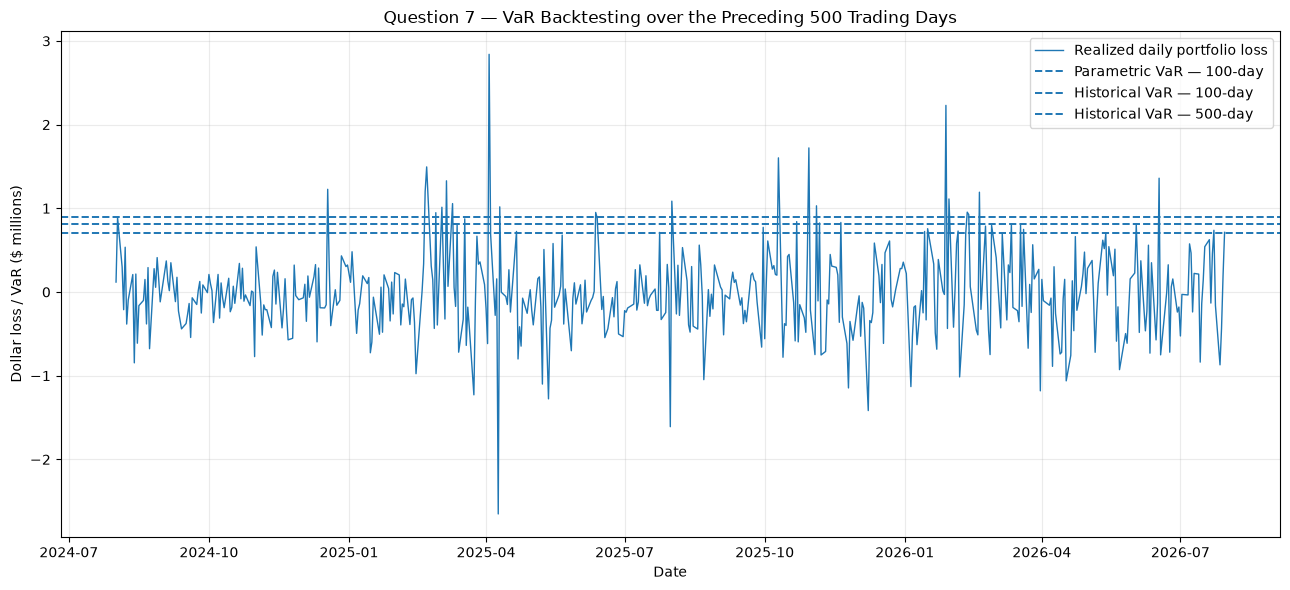

Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/figures/Q07_backtesting_exceptions.png


In [19]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)

ax.plot(
    backtest.index,
    backtest["portfolio_loss"] / 1_000_000,
    linewidth=1.0,
    label="Realized daily portfolio loss"
)

for _, row in thresholds.iterrows():

    ax.axhline(
        row["var_dollar"] / 1_000_000,
        linestyle="--",
        linewidth=1.4,
        label=row["method"]
    )

ax.set_title(
    "Question 7 — VaR Backtesting over the Preceding 500 Trading Days"
)

ax.set_xlabel("Date")
ax.set_ylabel("Dollar loss / VaR ($ millions)")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()

figure_path = (
    FIGURES /
    "Q07_backtesting_exceptions.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

## 9. Figure — exception-rate comparison

A horizontal line at 5% represents the benchmark exception rate for a 95% VaR.

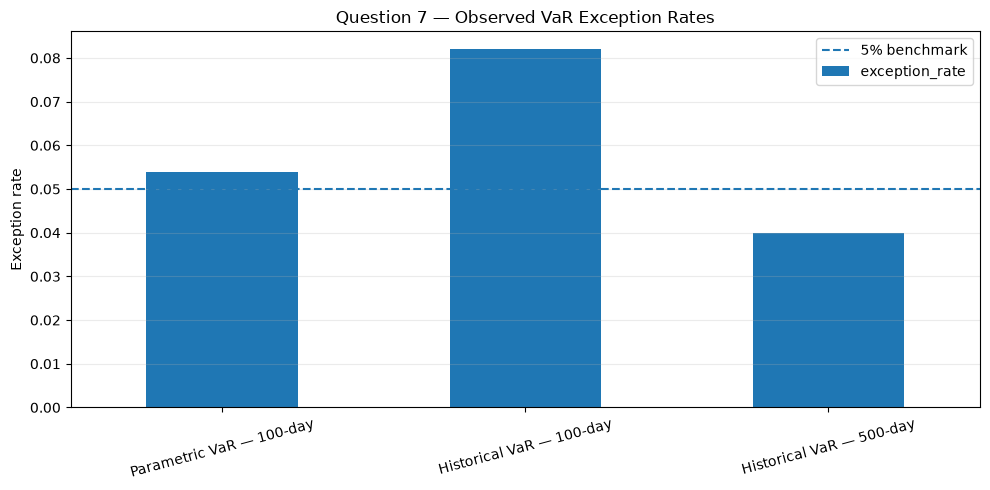

Saved: /Users/reza/Desktop/mfe-term 3/risk managment/VaR_Backtesting_as2/results/figures/Q07_exception_rates.png


In [20]:
plot_data = (
    backtest_summary
    .set_index("method")[
        "exception_rate"
    ]
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

plot_data.plot(
    kind="bar",
    ax=ax
)

ax.axhline(
    EXPECTED_RATE,
    linestyle="--",
    linewidth=1.5,
    label="5% benchmark"
)

ax.set_title(
    "Question 7 — Observed VaR Exception Rates"
)

ax.set_xlabel("")
ax.set_ylabel("Exception rate")

ax.tick_params(
    axis="x",
    rotation=15
)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

rate_path = (
    FIGURES /
    "Q07_exception_rates.png"
)

plt.savefig(
    rate_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", rate_path)

## 10. Report-ready table

In [21]:
report_table = backtest_summary[
    [
        "method",
        "var_dollar",
        "observations",
        "exceptions",
        "exception_rate",
        "expected_exceptions",
    ]
].copy()

display(
    report_table.style.format({
        "var_dollar": "${:,.0f}",
        "exception_rate": "{:.2%}",
        "expected_exceptions": "{:.0f}",
    })
)

,method,var_dollar,observations,exceptions,exception_rate,expected_exceptions
0,Parametric VaR — 100-day,"$807,196",500,27,5.40%,25
1,Historical VaR — 100-day,"$703,172",500,41,8.20%,25
2,Historical VaR — 500-day,"$892,489",500,20,4.00%,25


## Outputs created by Notebook 2

```text
results/tables/Q07_backtesting_results.csv
results/tables/Q07_exception_days.csv

results/figures/Q07_backtesting_exceptions.png
results/figures/Q07_exception_rates.png
```

##  Question 7 interpretation

Using the VaR estimates as of July 31, 2026, the last trading day on or before August 1, 2026, I evaluated the frequency of VaR exceptions over the preceding 500 trading days. An exception is defined as a day when the realized portfolio loss exceeds the corresponding VaR threshold. The 100-day parametric VaR was approximately $807,196$ and produced 27 exceptions (5.4%). The 100-day historical-simulation VaR was approximately $703,172$ and produced 41 exceptions (8.2%), while the 500-day historical-simulation VaR was approximately $892,489 and produced 20 exceptions (4.0%). For a 95% VaR, the expected exception rate is approximately 5%, corresponding to about 25 exceptions over 500 trading days. Therefore, the 100-day parametric VaR is the most closely calibrated of the three methods, with an observed exception rate of 5.4%. The 100-day historical VaR appears to underestimate tail risk because its exception rate is substantially above 5%, whereas the 500-day historical VaR is somewhat conservative, producing fewer exceptions than expected.

## Q 7 — Backtesting Results and Interpretation

Using the VaR estimates from **July 31, 2026**, the last trading day on or before August 1, 2026, I evaluated the number of VaR exceptions over the preceding **500 trading days**. An exception is defined as a day when the realized portfolio loss exceeds the corresponding VaR threshold.

The results are:

| Method | VaR Threshold | Exceptions | Exception Rate |
|---|---:|---:|---:|
| Parametric VaR — 100-day | $807,196 | 27 | 5.40% |
| Historical VaR — 100-day | $703,172 | 41 | 8.20% |
| Historical VaR — 500-day | $892,489 | 20 | 4.00% |

For a **95% VaR**, the expected exception rate is approximately **5%**. Therefore, over 500 trading days, the expected number of exceptions is

\[
500 \times 0.05 = 25.
\]

The **100-day parametric VaR** is the most closely calibrated of the three methods in this backtesting comparison. It produces **27 exceptions**, or **5.4%**, which is very close to the expected 5% rate.

The **100-day historical-simulation VaR** produces **41 exceptions**, corresponding to an exception rate of **8.2%**. Because this is substantially above the 5% benchmark, the model appears to **underestimate portfolio tail risk** during the backtesting period. Its VaR threshold is also the lowest of the three methods.

In contrast, the **500-day historical-simulation VaR** produces only **20 exceptions**, or **4.0%**. This is below the expected 5% rate, indicating that this estimate is somewhat **more conservative** over the backtesting period.

Overall, the results show that both the **VaR methodology** and the **length of the estimation window** materially affect the risk forecast. The shorter 100-day historical window produces a lower VaR and too many exceptions, while the longer 500-day historical window produces a higher and more conservative VaR. Among the three approaches, the **100-day parametric VaR provides the closest match to the expected 5% exception rate**.